## **UCI-HAR 가져오는 코드**
대충 모델 앞에 붙여서 쓰셈 ㅇㅇ\
드라이브에 올린 zip파일을 직접 해제하여 메모리에 올려서 사용

In [1]:
!unzip -q "/content/drive/MyDrive/deep/archive.zip" -d "/content/dataset/"

In [2]:
import numpy as np

In [3]:

INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [4]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/dataset/UCI-HAR Dataset/"

def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    X_signals = np.array(X_signals)
    return np.transpose(X_signals, (1, 2, 0))

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    return np.array(labels, dtype=np.int32) - 1

In [5]:
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt" for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt" for signal in INPUT_SIGNAL_TYPES
]

y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"


X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [6]:
print(X_train[0])
print(y_train[0])

[[ 1.808515e-04  1.076681e-02  5.556068e-02 ...  1.012817e+00
  -1.232167e-01  1.029341e-01]
 [ 1.013856e-02  6.579480e-03  5.512483e-02 ...  1.022833e+00
  -1.268756e-01  1.056872e-01]
 [ 9.275574e-03  8.928878e-03  4.840473e-02 ...  1.022028e+00
  -1.240037e-01  1.021025e-01]
 ...
 [-1.147484e-03  1.714439e-04  2.647864e-03 ...  1.018445e+00
  -1.240696e-01  1.003852e-01]
 [-2.222655e-04  1.574181e-03  2.381057e-03 ...  1.019372e+00
  -1.227451e-01  9.987355e-02]
 [ 1.575500e-03  3.070189e-03 -2.269757e-03 ...  1.021171e+00
  -1.213260e-01  9.498741e-02]]
4


In [ ]:
# # GPU 사용 가능 여부 확인 for pytorch
# device_available = torch.cuda.is_available()
# print(f"GPU 사용 가능 여부: {device_available}")

# if device_available:
#     device_name = torch.cuda.get_device_name(0)
#     print(f"사용 중인 GPU 장치: {device_name}")

#     device = torch.device("cuda")
#     x = torch.tensor([1.0, 2.0]).to(device)
#     print(f"텐서가 할당된 장치: {x.device}")
# else:
#     print("GPU를 인식하지 못했습니다. 설정을 다시 확인해주세요.")

# **모델**
1. ### SeparableConv1D 4개 쌓아서 테스트
2. ### Xception에서처럼 shortcut 추가해서 테스트

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

In [8]:
# Functional API 방식으로 작성.
inputs = layers.Input(shape=(128, 9))

x = layers.SeparableConv1D(64, 3, padding='same', activation=None)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

x = layers.SeparableConv1D(64, 3, padding='same', activation='relu')(x)
x = layers.SeparableConv1D(64, 3, padding='same', activation='relu')(x)
x = layers.SeparableConv1D(128, 3, padding='same', activation='relu')(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(6, activation='softmax')(x)

model = models.Model(inputs, outputs)


In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d                │ (None, 128, 64)        │           667 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_1              │ (None, 128, 64)        │         4,352 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_2              │ (None, 128, 64)        │         4,352 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_3              │ (None, 128, 128)       │         8,512 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,425 (138.38 KB)

 Trainable params: 35,297 (137.88 KB)

 Non-trainable params: 128 (512.00 B)

In [10]:
callbacks= [
    EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1
  )
]

In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, callbacks=callbacks)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.5414 - loss: 1.0569 - val_accuracy: 0.1856 - val_loss: 2.9217
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8094 - loss: 0.4460 - val_accuracy: 0.6621 - val_loss: 0.7494
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8764 - loss: 0.3207 - val_accuracy: 0.9300 - val_loss: 0.2524
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9135 - loss: 0.2329 - val_accuracy: 0.9041 - val_loss: 0.2533
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9167 - loss: 0.2227 - val_accuracy: 0.9041 - val_loss: 0.2488
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9265 - loss: 0.1908 - val_accuracy: 0.9143 - val_loss: 0.2248
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9269 - loss: 0.1921 - val_accuracy: 0.9055 - val_loss: 0.2381
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9398 - loss: 0.1530 - val_accuracy: 

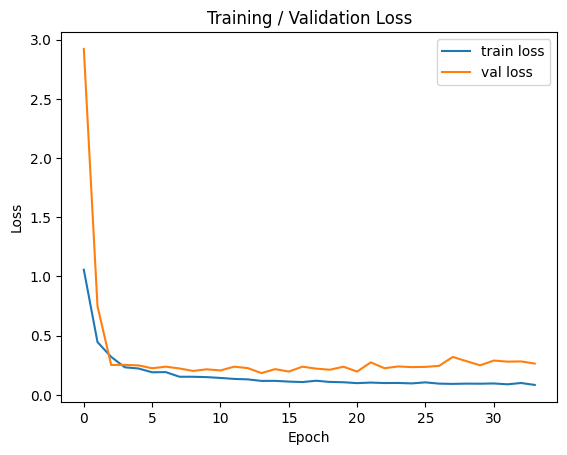

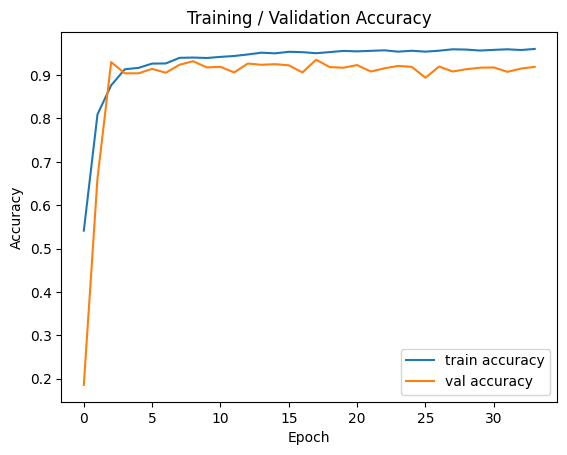

In [12]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training / Validation Accuracy')
plt.legend()

plt.show()

In [16]:
y_pred = model.predict(X_test)
loss, accuracy = model.evaluate(X_test, y_test)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9094 - loss: 0.3173


[[474   0  22   0   0   0]
 [ 33 414  24   0   0   0]
 [  2  11 407   0   0   0]
 [  0  21   0 379  86   5]
 [  2   4   0  56 470   0]
 [  0   0   1   0   0 536]]


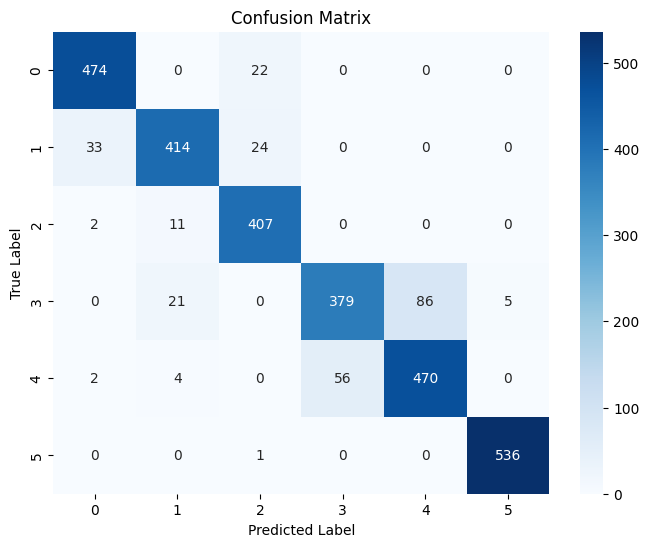

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, np.argmax(y_pred, axis=1))
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# **모델 2**

실제로 Residual connection을 적용해보자. Xception에서 그랬던 것처럼.


In [17]:
def xception_block(x, filters):
  shortcut = layers.Conv1D(filters, 1, padding='same')(x)

  x = layers.SeparableConv1D(filters, 3, padding='same', activation='relu')(x)
  x = layers.SeparableConv1D(filters, 3, padding='same', activation='relu')(x)
  x = layers.SeparableConv1D(filters, 3, padding='same', activation='relu')(x)

  x = layers.Add()([x, shortcut])
  x = layers.Activation('relu')(x)

  return x


In [18]:
inputs = layers.Input(shape=(128, 9))

x = layers.Conv1D(32, 3, padding='same', activation=None)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

x = xception_block(x, 64)
x = xception_block(x, 64)
x = xception_block(x, 128)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(6, activation='softmax')(x)

model2 = models.Model(inputs, outputs)

In [19]:
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 32)   │        896 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_4  │ (None, 128, 64)   │      2,208 │ activation_1[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_5  │ (None, 128, 64)   │      4,352 │ separable_conv1d… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_6  │ (None, 128, 64)   │      4,352 │ separable_conv1d… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 64)   │      2,112 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 64)   │          0 │ separable_conv1d… │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 64)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_7  │ (None, 128, 64)   │      4,352 │ activation_2[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_8  │ (None, 128, 64)   │      4,352 │ separable_conv1d… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_9  │ (None, 128, 64)   │      4,352 │ separable_conv1d… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 64)   │      4,160 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 64)   │          0 │ separable_conv1d… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 64)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_10 │ (None, 128, 128)  │      8,512 │ activation_3[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_11 │ (None, 128, 128)  │     16,896 │ separable_conv1d

 Total params: 99,174 (387.40 KB)

 Trainable params: 99,110 (387.15 KB)

 Non-trainable params: 64 (256.00 B)

In [20]:
callbacks= [
    EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1
  )
]

In [21]:
model2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model2.fit(X_train, y_train, validation_split=0.2, epochs=50, callbacks=callbacks)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 39s 80ms/step - accuracy: 0.7669 - loss: 0.6028 - val_accuracy: 0.5289 - val_loss: 1.2707
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9172 - loss: 0.2211 - val_accuracy: 0.9143 - val_loss: 0.2387
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9361 - loss: 0.1602 - val_accuracy: 0.9252 - val_loss: 0.2139
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9391 - loss: 0.1508 - val_accuracy: 0.9341 - val_loss: 0.1971
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9473 - loss: 0.1229 - val_accuracy: 0.9327 - val_loss: 0.2298
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9497 - loss: 0.1214 - val_accuracy: 0.9089 - val_loss: 0.2448
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9520 - loss: 0.1089 - val_accuracy: 0.9184 - val_loss: 0.2219
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9544 - loss: 0.0997 - val_acc

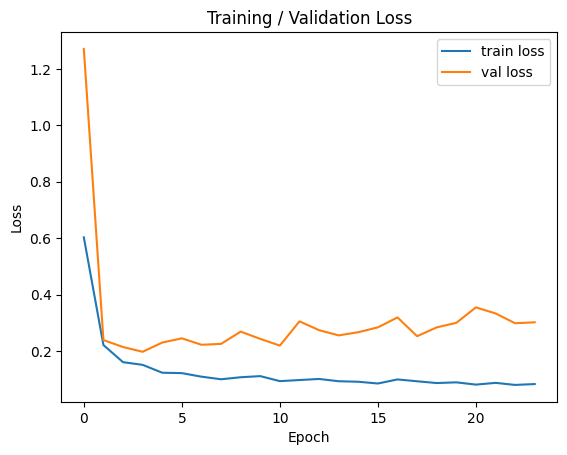

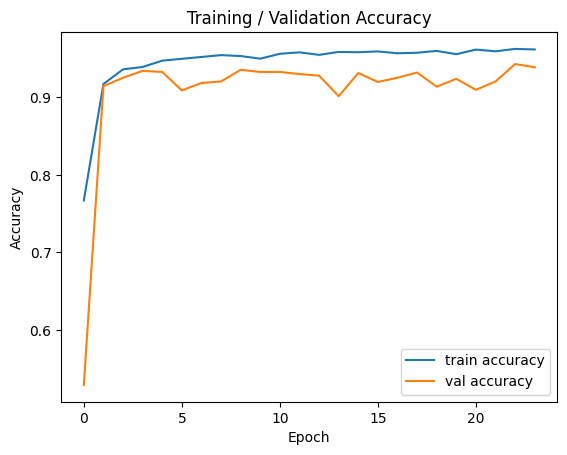

In [24]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training / Validation Accuracy')
plt.legend()

plt.show()

In [23]:
y_pred = model2.predict(X_test)
loss, accuracy = model2.evaluate(X_test, y_test)

93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8989 - loss: 0.2848


[[457   1  38   0   0   0]
 [ 21 417  33   0   0   0]
 [  2   0 418   0   0   0]
 [  3   5   0 412  71   0]
 [  0   3   0  97 432   0]
 [  0  24   0   0   0 513]]


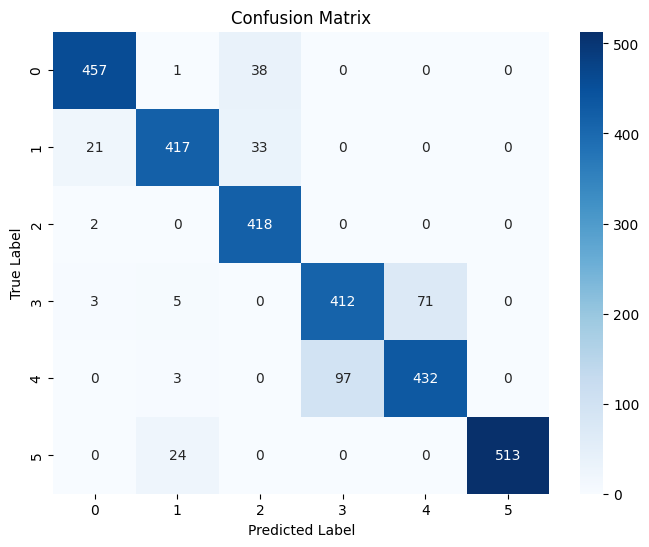

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, np.argmax(y_pred, axis=1))
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()